### Importing liberies

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import seaborn as sns

## Over view:
1. hotel: Type of hotel – City Hotel or Resort Hotel.
2. is_canceled: Indicates if the booking was canceled (1) or not (0).
3. lead_time: Number of days between booking and actual arrival.
4. lead_time: Number of days between booking and actual arrival.
5. arrival_date_year, arrival_date_month, arrival_date_week_number, arrival_date_day_of_month:   Detailed arrival date info.
6. stays_in_weekend_nights: Nights stayed during weekends.
7. stays_in_week_nights: Nights stayed during weekdays.
8. adults, children, babies: Number of guests of each type.
9. meal: Type of meal booked (e.g., BB = Bed & Breakfast).
10. country: Guest's country of origin.
11. market_segment: How the booking was made (e.g., Online TA = Travel Agency).
12. distribution_channel: Booking distribution channel.
13. Reservation Status:reservation_status,reservation_status_date
14. Customer Behavior:is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list
15. Customer Type & Requests:customer_type,adr,required_car_parking_spaces,total_of_special_requests


### Read the file and check the basic info

In [2]:
df=pd.read_csv(r"C:\Users\acer\Desktop\data science\ED\hotel_bookings.csv")

In [3]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
df.nunique()

hotel                                2
is_canceled                          2
lead_time                          479
arrival_date_year                    3
arrival_date_month                  12
arrival_date_week_number            53
arrival_date_day_of_month           31
stays_in_weekend_nights             17
stays_in_week_nights                35
adults                              14
children                             5
babies                               5
meal                                 5
country                            177
market_segment                       8
distribution_channel                 5
is_repeated_guest                    2
previous_cancellations              15
previous_bookings_not_canceled      73
reserved_room_type                  10
assigned_room_type                  12
booking_changes                     21
deposit_type                         3
agent                              333
company                            352
days_in_waiting_list     

In [6]:
df.duplicated().sum()

31994

In [7]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [8]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [9]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [10]:
df.fillna({'country':'other'},inplace=True)

In [11]:
df.dropna(subset=['children'],inplace=True)

In [12]:
df.fillna({'agent':'86.693382'},inplace=True)

In [13]:
df.fillna({'company':'189.266735'},inplace=True)

## Visualizing the data by plots

C:\Users\acer\AppData\Local\Temp\ipykernel_14564\4273268734.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="hotel", palette="viridis")


Text(0, 0.5, 'Number of Bookings')

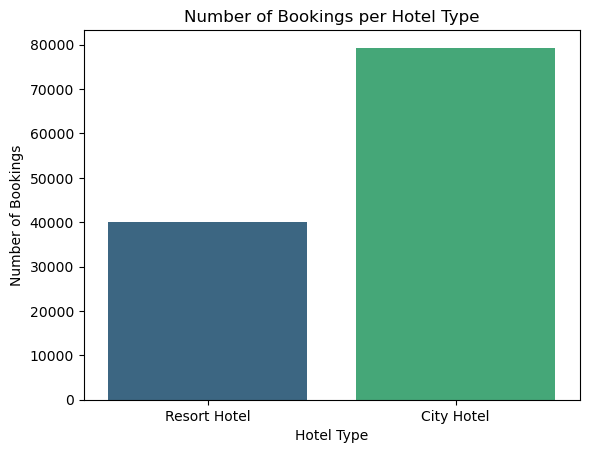

In [14]:
sns.countplot(data=df, x="hotel", palette="viridis")
plt.title("Number of Bookings per Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")

### City hotels have the more bookings than the resort hotel

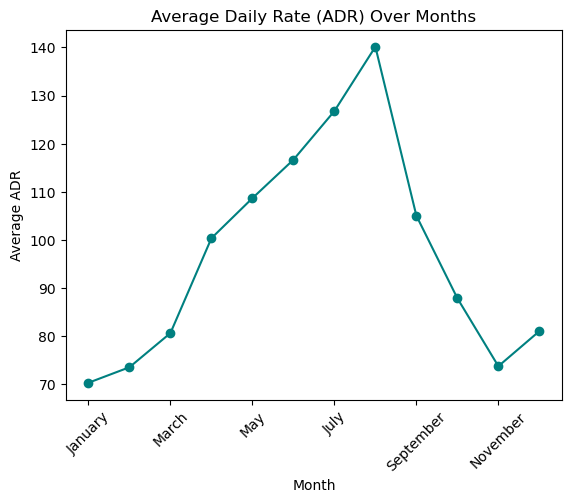

In [15]:
month_order = ["January", "February", "March", "April", "May", "June", 
               "July", "August", "September", "October", "November", "December"]
monthly_adr = df.groupby("arrival_date_month")["adr"].mean().reindex(month_order)
monthly_adr.plot(kind="line", marker='o', color='teal')
plt.title("Average Daily Rate (ADR) Over Months")
plt.xlabel("Month")
plt.ylabel("Average ADR")
plt.xticks(rotation=45)
plt.show()

### Avg daily rate is very high in July,August and september months

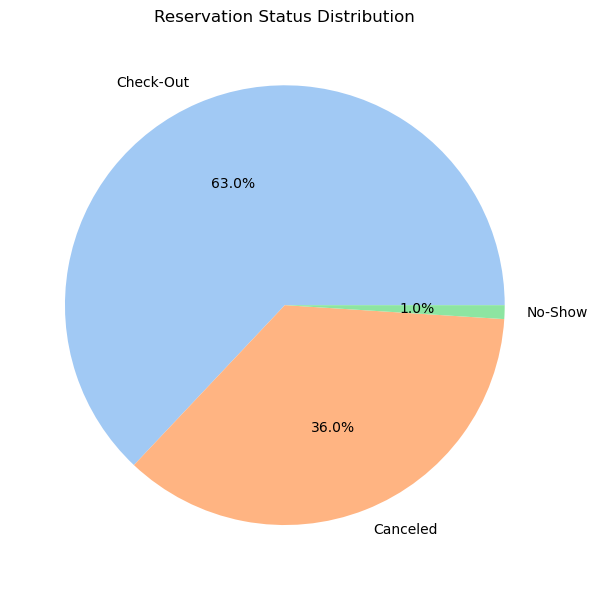

In [16]:
plt.figure(figsize=(8,6))
status_counts = df["reservation_status"].value_counts()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title("Reservation Status Distribution")
plt.tight_layout()
plt.show()

### 36% of customers are canceled the reserved city hotel or resorts

C:\Users\acer\AppData\Local\Temp\ipykernel_14564\1654094566.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="hotel", y="adr", palette="Set3")


Text(0.5, 0, 'Hotel Type')

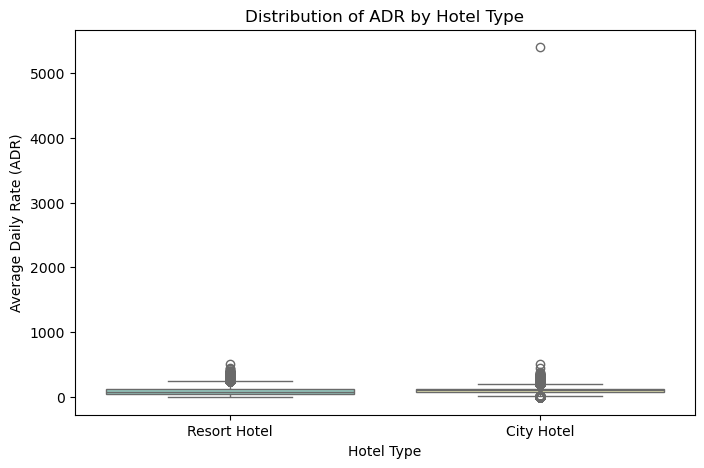

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="hotel", y="adr", palette="Set3")
plt.title("Distribution of ADR by Hotel Type")
plt.ylabel("Average Daily Rate (ADR)")
plt.xlabel("Hotel Type")

### This shows how the daily rates vary for each hotel, including outliers and distribution spread.

C:\Users\acer\AppData\Local\Temp\ipykernel_14564\2411538388.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="customer_type", palette="Blues", order=df['customer_type'].value_counts().index)


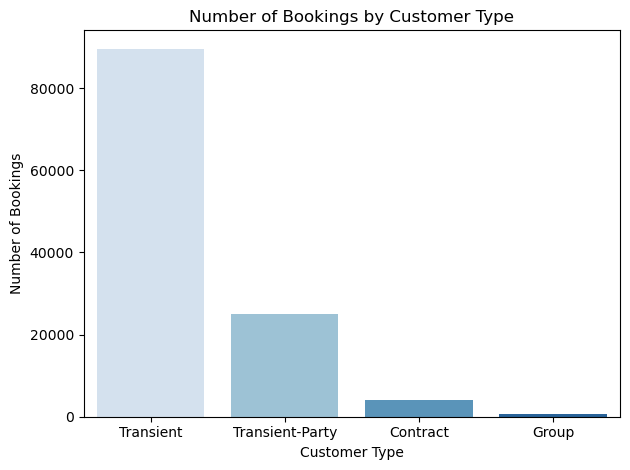

In [18]:
sns.countplot(data=df, x="customer_type", palette="Blues", order=df['customer_type'].value_counts().index)
plt.title("Number of Bookings by Customer Type")
plt.ylabel("Number of Bookings")
plt.xlabel("Customer Type")

plt.tight_layout()
plt.show()

### Transient customers are more booking the hotels than the other customers

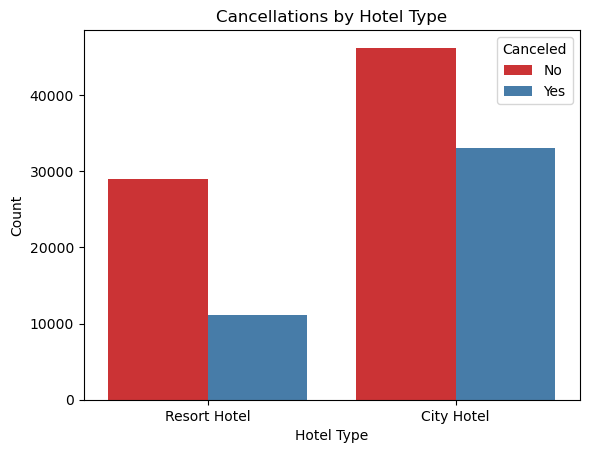

In [19]:
sns.countplot(data=df, x="hotel", hue="is_canceled", palette="Set1")
plt.title("Cancellations by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Count")
plt.legend(title="Canceled", labels=["No", "Yes"])

### City hotels is canceled by the customers more than the resort hotel

C:\Users\acer\AppData\Local\Temp\ipykernel_14564\1175044849.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=special_requests, x="hotel", y="total_of_special_requests", palette="Blues_d")


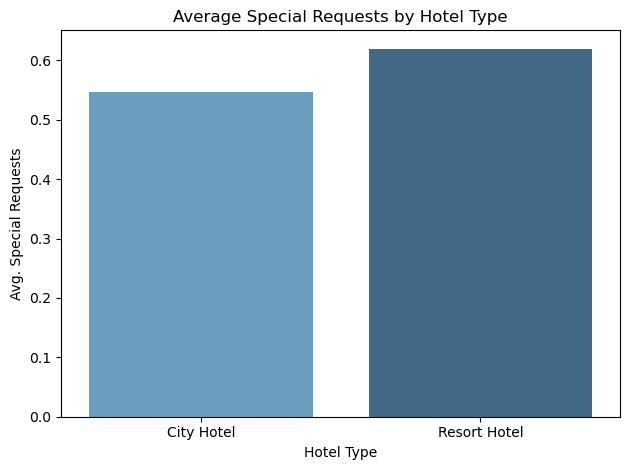

In [20]:
special_requests = df.groupby("hotel")["total_of_special_requests"].mean().reset_index()
sns.barplot(data=special_requests, x="hotel", y="total_of_special_requests", palette="Blues_d")
plt.title("Average Special Requests by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Avg. Special Requests")
plt.tight_layout()
plt.show()

### The resort hotel has got the more special request for customization than the city hotel

## conclusion
* City hotels have the more bookings than the resort hotel
* Avg daily rate is very high in July,August and september months
* 36% of customers are canceled the reserved city hotel or resorts
* This shows how the daily rates vary for each hotel, including outliers and distribution spread.
* Transient customers are more makes the than the other customers
* City hotels is canceled by the customers more than the resort hotel
* The resort hotel has got the more special request for customization than the city hotel